### Keras: Erste Versuche

#### 1) Daten laden

In [22]:
import pandas as pd
from math import ceil

pd.set_option('display.max_columns', 6)

data_url=r'https://raw.githubusercontent.com/rawe64/ai/main/ndx100.csv'
df = pd.read_csv(data_url)
df.head()

,m199,m99,m49,...,m3,m1,p5
0,-34.023668,-24.908597,-26.302555,...,-3.567182,0.328812,-5.638866
1,-45.493319,-34.786439,-31.315602,...,-10.180812,-5.099538,-6.134486
2,-42.415836,-36.541864,-34.279911,...,-4.975005,-0.211015,-6.591711
3,-53.283988,-36.786283,-40.070083,...,-9.990068,-4.432868,-6.060527
4,-40.239003,-34.040967,-29.901523,...,1.331406,5.718546,-9.906045


#### 2) x-/y-Daten selektieren und standardisieren

In [23]:
from sklearn.preprocessing import StandardScaler

X = df[['m199', 'm99','m49','m19','m9','m5','m3','m1']].values
y = df[['p5']].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

X.shape, y.shape

((6185, 8), (6185, 1))

#### 3) Keras-Modell aufbauen

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input # Import Input layer

# Good practice: Start with an Input layer
model = Sequential([
    Input(shape=(8,)), # Explicitly define input shape
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary() # This will work immediately and show all layers and shapes

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 4) Modell kompilieren


In [25]:
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD

mse = MeanSquaredError()
sgd = SGD(learning_rate=0.005)
model.compile(loss=mse, optimizer=sgd)

#### 5) Modell anlernen

In [26]:
history = model.fit(X, y, epochs=50, batch_size=16)

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2218
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0770
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0372
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9942
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0304
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0217
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0117
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9600
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9954
Epoch 10/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9507
Epoch 11/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9767
Epoch 12/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9948
Epoch 13/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0135
Epoch 14/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0209
Epoch 15/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

#### 6) Nach dem Anlernen

##### Gewichte abfragen:

In [27]:
weights = model.get_layer(index=0).get_weights()
weights

[array([[ 7.07305372e-02,  2.76169956e-01,  6.56289160e-02,
          1.27332285e-01,  2.34219953e-01,  9.93454158e-02,
          9.79242176e-02,  2.26271912e-01, -1.46925747e-01,
         -1.38552621e-01,  2.92924773e-02,  5.02365567e-02,
          1.37534872e-01, -1.41183376e-01,  2.07398653e-01,
         -1.33986278e-02,  1.01217307e-01, -2.27946967e-01,
         -2.16768429e-01, -2.87422389e-01,  1.18761696e-01,
          1.22586638e-02, -2.48873681e-01,  1.44814581e-01,
         -2.45470181e-01,  2.07811609e-01,  1.60400882e-01,
          2.45738789e-01, -2.25716099e-01, -6.88536614e-02,
          1.46219030e-01, -7.48694837e-02,  3.74249257e-02,
          2.08627135e-01,  8.86751264e-02, -1.08165815e-01,
         -6.31643385e-02,  2.79147118e-01, -8.25886354e-02,
         -1.25400633e-01,  2.33632520e-01, -2.82930601e-02,
          7.82189667e-02, -2.17343599e-01, -1.12546772e-01,
         -2.40044907e-01,  1.21576712e-01,  2.52956413e-02,
          5.64473011e-02,  8.71235058e-0

##### Schätzungen für einen Beispieldatensatz erzeugen:

In [28]:
X_pred = [[13.4281648769462,2.03529417147459,16.0717962326652,4.30356464726417,0.267199846268572,1.03082406445738,0.627736625137835,1.05187062769086]]
X_pred = scaler_X.transform(X_pred)
y_pred = model.predict(X_pred)
y_pred = scaler_y.inverse_transform(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[0.2787251]], dtype=float32)

#### 7) Evaluation

##### R-Quadrat:

In [29]:
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print('r2 = {:.3f}'.format(r2))

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
r2 = 0.005


#### 8) Anlernprozess graphisch darstellen

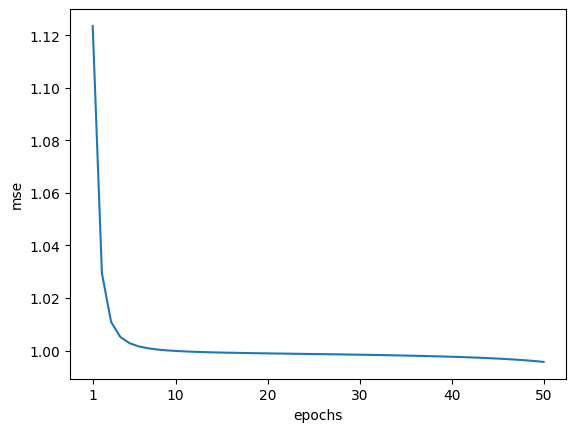

In [30]:
import matplotlib.pyplot as plt

loss_mse = history.history['loss']
plt.xticks([1,10,20,30,40,50])
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)